In [1]:
import numpy as np
import os
import glob
import yaml
import matplotlib.pyplot as plt
import fivebeads
import json
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.transforms as mtrans


parent_dir = "/Volumes/Bit Bank 1/Research/Neural_Estimation/N_dis3"
coarse_steps= ["01", "02", "03", "04", "05", "06", "10", "12", "15"]
num_trials = 12

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

folders = sorted([f for f in os.listdir(parent_dir) if os.path.isdir(os.path.join(parent_dir, f))])


N = []
for folder in folders:
    yaml_file_path = os.path.join(parent_dir, folder, "config.yaml")
    with open(yaml_file_path, "r") as file:
        config = yaml.safe_load(file)
    num_paths = config.get('training', {}).get('epoch_s')
    N.append(num_paths)
N, folders

([40000, 400000, 8000, 160000, 800000, 16000, 80000],
 ['03_07_15_3712',
  '03_07_17_5701',
  '03_08_11_3642',
  '03_08_11_5739',
  '03_08_19_4608',
  '03_09_09_5331',
  '03_10_11_2722'])

In [2]:
r2 = np.zeros((len(N), len(coarse_steps), 2, num_trials))
for folder in folders:
    file_path = os.path.join(parent_dir, folder, "theo_final_diss.npy")
    # theo has the shape of (num_trials, num_paths)
    theo = np.load(file_path)
    for i in coarse_steps:
        file_path = os.path.join(parent_dir, folder, f"nn_final_diss_cum_coarse_{i}.npz")
        nn = np.load(file_path)
        r2_first=[]
        r2_second=[]
        # j is the index for trials theo has shape (12, num_paths)
        for j in range(0,num_trials):
            r2_first.append(r2_score(theo[j,:],nn['first_order'].sum(axis=-1)[j,:]))
            r2_second.append(r2_score(theo[j,:],nn['second_order'].sum(axis=-1)[j,:]))
        r2[folders.index(folder), coarse_steps.index(i), 0,:] = r2_first
        r2[folders.index(folder), coarse_steps.index(i), 1,:] = r2_second




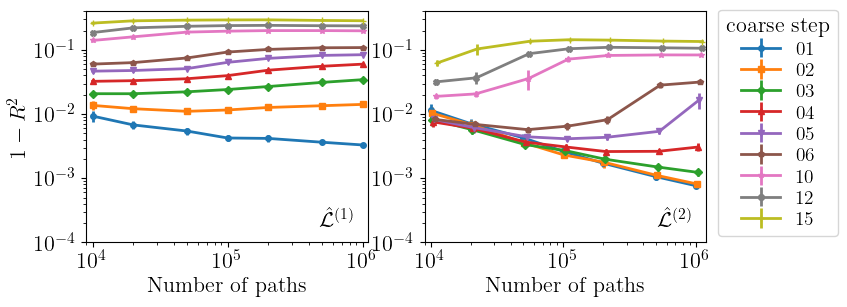

In [16]:
# Load JSON configuration
with open("plot_config.json", "r") as f:
    config = json.load(f)

# Apply settings to rcParams
plt.rcParams.update(config)
fig,ax = plt.subplots(1,2)
loc = 'upper right'


markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'X', '+', '|']
for i in coarse_steps:
    r2_mean = r2[:, coarse_steps.index(i), 0, :].mean(axis=1)
    r2_std = r2[:, coarse_steps.index(i), 0, :].std(axis=1)
    sorted_indices = np.argsort(N)
    N_sorted = np.array(N)[sorted_indices]*10/8
    r2_mean_sorted = r2_mean[sorted_indices]
    r2_std_sorted = r2_std[sorted_indices]    
    ax[0].errorbar(N_sorted, 1-r2_mean_sorted, yerr=r2_std_sorted, label=f" {i}", marker=markers[coarse_steps.index(i)], markersize=4, linewidth=2, alpha=1)
    #ax[0].legend(title="",title_fontsize=16, ncol=1, loc=loc, fontsize=16, bbox_to_anchor=(1.15, 1))
    ax[0].set_xscale('log')
    ax[0].set_yscale('log')
    ax[0].set_xlim([.9e4, 1.1e6])
    ax[0].set_ylim([0.0001, 0.4])
#ax[0].plot([1e3, 2e6], [1, 1], 'k--')
ax[0].set_xlabel("Number of paths", fontsize=16)
ax[0].set_ylabel("$1-R^2$", fontsize=16)
ax[0].text(0.95, 0.05, r'$\hat{\mathcal{L}}^{(1)}$', horizontalalignment='right', verticalalignment='bottom', transform=ax[0].transAxes)
#fig.savefig("figs/r2_first_order_dis1.pdf")

for i in coarse_steps:
    r2_mean = r2[:, coarse_steps.index(i), 1, :].mean(axis=1)
    r2_std = r2[:, coarse_steps.index(i), 1, :].std(axis=1)
    ############
    sorted_indices = np.argsort(N)
    N_sorted = np.array(N)[sorted_indices]*10/8
    r2_mean_sorted = r2_mean[sorted_indices]
    r2_std_sorted = r2_std[sorted_indices]  
    ###########
    ax[1].errorbar(N_sorted*(1.00+0.015*coarse_steps.index(i)),1- r2_mean_sorted, yerr=r2_std_sorted, label=f" {i}", marker=markers[coarse_steps.index(i)], markersize=4, linewidth=2, alpha=1)
    ax[1].legend(title="coarse step",title_fontsize=16, ncol=1, labelspacing=0.2, loc=loc, fontsize=14, bbox_to_anchor=(1.5, 1.05))
    ax[1].set_xscale('log')
    ax[1].set_yscale('log')
    ax[1].set_xlim([0.9e4, 1.2e6])
    ax[1].set_ylim([0.0001, 0.4])
#ax[1].plot([1e3, 2e6], [1, 1], 'k--')
ax[1].set_xlabel("Number of paths", fontsize=16)
ax[1].text(0.95, 0.05, r'$\hat{\mathcal{L}}^{(2)}$', horizontalalignment='right', verticalalignment='bottom', transform=ax[1].transAxes)

#plt.ylabel("$R^2$")
plt.savefig("figs/r2_N_dis3.pdf", bbox_inches='tight')



### entropy mean


In [10]:
ent_mean = np.zeros((len(N),len(coarse_steps), 2, num_trials))
for folder in folders:
    file_path = os.path.join(parent_dir, folder, "theo_final_diss.npy")
    theo = np.load(file_path)
    for i in coarse_steps:
        file_path = os.path.join(parent_dir, folder, f"nn_final_diss_cum_coarse_{i}.npz")
        nn = np.load(file_path)
        ent_mean[folders.index(folder), coarse_steps.index(i), 0,:]=nn["first_order"].sum(axis=-1).mean(axis=1)
        ent_mean[folders.index(folder), coarse_steps.index(i), 1,:]=nn["second_order"].sum(axis=-1).mean(axis=1)

<>:26: SyntaxWarning: invalid escape sequence '\h'
<>:26: SyntaxWarning: invalid escape sequence '\h'
/var/folders/zd/w4zsltpn7gv1q6whwcjvq61w0000gw/T/ipykernel_3560/1529906081.py:26: SyntaxWarning: invalid escape sequence '\h'
  ax[0].set_ylabel("$\hat{\Sigma}/\Sigma$")


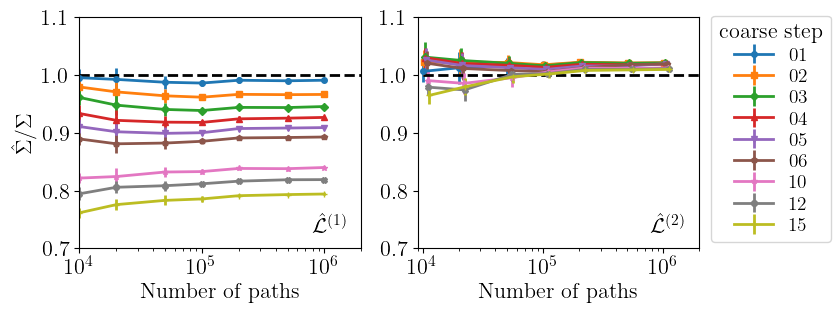

In [15]:
# Load JSON configuration
with open("plot_config.json", "r") as f:
    config = json.load(f)
loc = 'upper right'
# Apply settings to rcParams
plt.rcParams.update(config)

fig,ax = plt.subplots(1,2)
markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'X', '+', '|']
for i in coarse_steps:
    mean = ent_mean[:, coarse_steps.index(i), 0, :].mean(axis=1)
    std = ent_mean[:, coarse_steps.index(i), 0, :].std(axis=1)
    ############
    sorted_indices = np.argsort(N)
    N_sorted = np.array(N)[sorted_indices]*10/8
    mean_sorted = mean[sorted_indices]/theo.mean()
    std_sorted = std[sorted_indices]/theo.mean()
    ###########
    ax[0].errorbar(N_sorted, mean_sorted, yerr=std_sorted, label=f"{i}", marker=markers[coarse_steps.index(i)], markersize=4, linewidth=2, alpha=1)
    ax[0].set_xscale('log')
    ax[0].set_xlim([1e4, 2e6])
    ax[0].set_ylim([0.7, 1.10])
    #ax[0].set_yscale('log')
ax[0].plot([1e4, 2e6], [1, 1], 'k--')
ax[0].set_xlabel("Number of paths")
ax[0].set_ylabel("$\hat{\Sigma}/\Sigma$")
ax[0].text(0.95, 0.05, r'$\hat{\mathcal{L}}^{(1)}$', horizontalalignment='right', verticalalignment='bottom', transform=ax[0].transAxes)



#ax0_inset = inset_axes(ax[0], width="60%", height="60%", loc="lower right", bbox_to_anchor=(-0.0, 0.05, 1.0, 1.0), 
#                      bbox_transform=ax[0].transAxes)  # Adjust size and position

#for i in coarse_steps:
#    r2_mean = r2[:, coarse_steps.index(i), 0, :].mean(axis=1)
#    r2_std = r2[:, coarse_steps.index(i), 0, :].std(axis=1)
    ############
#    sorted_indices = np.argsort(N)
#    N_sorted = np.array(N)[sorted_indices]*10/8
#    r2_mean_sorted = r2_mean[sorted_indices]
#    r2_std_sorted = r2_std[sorted_indices]  
    ###########
#    ax0_inset.errorbar(N_sorted,1- r2_mean_sorted, yerr=r2_std_sorted, label=f" {i}", marker=markers[coarse_steps.index(i)], markersize=4, linewidth=2, alpha=1)
    #ax_inset.legend(title="coarse step",title_fontsize=16, ncol=1, labelspacing=1.5, loc=loc, fontsize=16, bbox_to_anchor=(1.25, 1))
#    ax0_inset.set_xscale('log')
#    ax0_inset.set_yscale('log')
#    ax0_inset.set_xlim([0.9e4, 1.1e6])
#    ax0_inset.set_ylim([0.001, 0.2])
#    ax0_inset.set_ylabel("$1-R^2$")

##########################################

for i in coarse_steps:
    mean = ent_mean[:, coarse_steps.index(i), 1, :].mean(axis=1)
    std = ent_mean[:, coarse_steps.index(i), 1, :].std(axis=1)
    ############
    sorted_indices = np.argsort(N)
    N_sorted = np.array(N)[sorted_indices]*10/8
    mean_sorted = mean[sorted_indices]/theo.mean()
    std_sorted = std[sorted_indices]/theo.mean()
    ###########
    ax[1].errorbar(N_sorted*(1.00+0.015*coarse_steps.index(i)), mean_sorted, yerr=std_sorted, label=f" {i}", marker=markers[coarse_steps.index(i)], markersize=4, linewidth=2, alpha=1)
    ax[1].legend(title="coarse step",title_fontsize=16, ncol=1, labelspacing=.2, loc=loc, fontsize=14, bbox_to_anchor=(1.5, 1.05))
    ax[1].set_xscale('log')
    ax[1].set_ylim([0.7, 1.10])
    #ax[1].set_yscale('log')
    ax[1].set_xlim([0.9e4, 2e6])
ax[1].plot([1e4, 2e6], [1, 1], 'k--')

ax[1].set_xlabel("Number of paths")
ax[1].text(0.95, 0.05, r'$\hat{\mathcal{L}}^{(2)}$', horizontalalignment='right', verticalalignment='bottom', transform=ax[1].transAxes)


#ax1_inset = inset_axes(ax[1], width="60%", height="60%", loc="lower right", bbox_to_anchor=(-0.0, 0.05, 1.0, 1.0), 
#                      bbox_transform=ax[1].transAxes)  # Adjust size and position

#for i in coarse_steps:
#    r2_mean = r2[:, coarse_steps.index(i), 1, :].mean(axis=1)
#    r2_std = r2[:, coarse_steps.index(i), 1, :].std(axis=1)
    ############
#    sorted_indices = np.argsort(N)
#    N_sorted = np.array(N)[sorted_indices]*10/8
#    r2_mean_sorted = r2_mean[sorted_indices]
#    r2_std_sorted = r2_std[sorted_indices]  
    ###########
#    ax1_inset.errorbar(N_sorted*(1.00+0.015*coarse_steps.index(i)),1- r2_mean_sorted, yerr=r2_std_sorted, label=f" {i}", marker=markers[coarse_steps.index(i)], markersize=4, linewidth=2, alpha=1)
    #ax_inset.legend(title="coarse step",title_fontsize=16, ncol=1, labelspacing=1.5, loc=loc, fontsize=16, bbox_to_anchor=(1.25, 1))
#    ax1_inset.set_xscale('log')
#    ax1_inset.set_yscale('log')
#    ax1_inset.set_xlim([0.9e4, 1.1e6])
#    ax1_inset.set_ylim([0.001, 0.2])
#    ax1_inset.set_ylabel("$1-R^2$")

#ax[1].set_ylabel("$\hat{\Sigma}/\Sigma$")
#ax[1].plot([1e3, 2e6], [1, 1], 'k--')
#ax_inset.set_title("Inset Plot", fontsize=10)
plt.savefig("figs/ent_N_dis3.pdf",bbox_inches='tight')
